In [1]:
!pip install -U pandas numpy scikit-learn openpyxl
!pip install -U pandas numpy scikit-learn openpyxl shap matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, pandas as pd

TCRI_PATH = "tcri.csv"
FIN_PATH  = "ratios_filled_with_gics_category.csv"
OUT_DIR_GICS = "outputs/logistic_baseline"
OUT_DIR_BASE = "outputs/logistic_baseline_no_gics"
MERGED_PATH = os.path.join(OUT_DIR_GICS, "merged.csv")

for d in [OUT_DIR_GICS, OUT_DIR_BASE]:
    os.makedirs(d, exist_ok=True)
os.environ["OUT_DIR"] = OUT_DIR_GICS
os.environ["OUT_DIR_GICS"] = OUT_DIR_GICS
os.environ["OUT_DIR_BASE"] = OUT_DIR_BASE
os.environ["MERGED_PATH"] = MERGED_PATH

print("tcri.csv exists?", os.path.exists(TCRI_PATH))
print("ratios_filled_with_gics_category.csv exists?", os.path.exists(FIN_PATH))


tcri.csv exists? True
ratios_filled_with_gics_category.csv exists? True


In [3]:
import os, json, pandas as pd
OUT_DIR_GICS = os.environ['OUT_DIR_GICS']
MERGED_PATH = os.environ['MERGED_PATH']

!python merge_tcri_and_ratios.py \
  --tcri "$TCRI_PATH" \
  --ratios  "$FIN_PATH" \
  --ratios-date-format "%Y/%m" \
  --dedup-ratios \
  --out "$MERGED_PATH"

# 預覽前 5 列
merged = pd.read_csv(MERGED_PATH, parse_dates=['mdate'])
merged.head()


[INFO] Dropped 88 duplicate rows from ratios data based on (id,date)
[INFO] Merged shape: (6383, 19). Saved to /Users/chieh.1227/repo/ML/outputs/logistic_baseline/merged.csv


,coid,mdate,tcri,scr,xcdt,company,WorkingCapital_TotalAssets,RetainedEarnings_TotalAssets,CashFlow_TotalDebt,TotalDebt_TotalAssets,CurrentRatio,stock_prefix,WorkingCapital_TotalAssets_miss,RetainedEarnings_TotalAssets_miss,CashFlow_TotalDebt_miss,TotalDebt_TotalAssets_miss,CurrentRatio_miss,產業別,GICS_Category
0,1103,2014-12-01,6,400.0,NaN,1103 嘉泥,0.248834,0.222521,0.031686,0.355758,1.573942,11,0,0,0,0,0,水泥工業,9
1,1103,2015-12-01,6,432.0,NaN,1103 嘉泥,0.288490,0.266805,0.022494,0.396789,2.079358,11,0,0,0,0,0,水泥工業,9
2,1103,2016-12-01,6,371.0,NaN,1103 嘉泥,0.251213,0.276883,0.039433,0.332750,1.751954,11,0,0,0,0,0,水泥工業,9
3,1103,2017-12-01,6,330.0,NaN,1103 嘉泥,0.214906,0.277971,0.043575,0.277508,1.595351,11,0,0,0,0,0,水泥工業,9
4,1103,2018-12-01,6,331.0,NaN,1103 嘉泥,0.222120,0.264199,-0.055883,0.297109,1.501782,11,0,0,0,0,0,水泥工業,9


In [4]:
%%writefile tcri_baseline_logit.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TCRI Baseline (Benchmark) — Logistic Regression pipeline entry point.

This script now orchestrates three stages:
1. Data ingestion / label creation (src.data_prep)
2. Model training and calibration (src.modeling.logistic_pipeline)
3. Evaluation + artifact export (src.reporting)
"""
from __future__ import annotations

import argparse
import os

import numpy as np

from src.data_prep import create_label_next_period, detect_feature_columns, load_and_prepare, time_split
from src.explain import run_shap_for_model
from src.metrics import best_f1_threshold, threshold_at_precision
from src.modeling.logistic_pipeline import extract_feature_weights, predict_with_calibration, select_best_logistic_model
from src.reporting import aggregate_slice_metrics, evaluate_predictions, prepare_prediction_frame, save_artifacts


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="TCRI Logistic Baseline (no-industry ok)")
    p.add_argument("--csv", type=str, required=True)
    p.add_argument("--outdir", type=str, default="outputs/logistic_baseline")
    p.add_argument("--id-col", type=str, default="coid")
    p.add_argument("--date-col", type=str, default="mdate")
    p.add_argument("--tcri-col", type=str, default="tcri")
    p.add_argument(
        "--gics-col",
        type=str,
        default="GICS_Category",
        help="Optional categorical column representing GICS segments. Leave blank to ignore.",
    )
    p.add_argument("--tau", type=int, default=7)
    p.add_argument("--horizon", type=int, default=1)
    p.add_argument("--train-start", type=str, default="2014-01-01")
    p.add_argument("--train-end", type=str, default="2021-12-31")
    p.add_argument("--valid-start", type=str, default="2022-01-01")
    p.add_argument("--valid-end", type=str, default="2022-12-31")
    p.add_argument("--test-start", type=str, default="2023-01-01")
    p.add_argument("--test-end", type=str, default="2024-12-31")
    p.add_argument("--target-precision", type=float, default=0.5)
    p.add_argument("--random-state", type=int, default=42)
    return p.parse_args()


def main():
    args = parse_args()
    os.makedirs(args.outdir, exist_ok=True)

    gics_col = (args.gics_col or "").strip() or None
    categorical_cols = [c for c in [gics_col] if c]

    df = load_and_prepare(args.csv, args.id_col, args.date_col, None, args.tcri_col)
    df = create_label_next_period(df, args.id_col, args.tcri_col, args.tau, args.horizon)
    train, valid, test = time_split(
        df,
        args.date_col,
        args.train_start,
        args.train_end,
        args.valid_start,
        args.valid_end,
        args.test_start,
        args.test_end,
    )
    num_cols, cat_cols = detect_feature_columns(
        train,
        args.id_col,
        args.date_col,
        args.tcri_col,
        categorical_cols=categorical_cols,
    )

    Cs = [0.1, 1.0, 10.0]
    best_model, best_C, best_score = select_best_logistic_model(
        train, valid, num_cols, cat_cols, Cs=Cs, random_state=args.random_state
    )
    valid_features = valid[num_cols + cat_cols]
    test_features = test[num_cols + cat_cols]
    p_valid_best = best_model.predict_proba(valid_features)[:, 1]
    t_f1 = best_f1_threshold(valid["y"].values, p_valid_best)
    t_rp = threshold_at_precision(valid["y"].values, p_valid_best, args.target_precision)
    print(f"[INFO] Selected C={best_C} by PR-AUC on validation ({best_score:.4f})")
    print(f"[INFO] Thresholds on validation: t_f1={t_f1:.4f}, t_at_P>={args.target_precision:.2f} = {t_rp:.4f}")

    calibrated_probs = predict_with_calibration(best_model, valid_features, valid["y"], test_features)
    metrics = evaluate_predictions(test["y"].values, calibrated_probs, threshold=t_f1, target_precision=args.target_precision)
    metrics["thresholds"] = {"t_f1": t_f1, "t_at_precision": t_rp, "precision_target": args.target_precision}
    metrics["valid_pr_auc_for_bestC"] = float(best_score)
    metrics["chosen_C"] = float(best_C)

    slice_tables = {
        "quarter": aggregate_slice_metrics(
            test, calibrated_probs, "quarter", threshold=t_f1, target_precision=args.target_precision
        )
    }
    for col in categorical_cols:
        table = aggregate_slice_metrics(test, calibrated_probs, col, threshold=t_f1, target_precision=args.target_precision)
        if not table.empty:
            slice_tables[col] = table
    preds = prepare_prediction_frame(test, args.id_col, args.date_col, calibrated_probs)
    feature_weights = extract_feature_weights(best_model)
    save_artifacts(preds, metrics, feature_weights, slice_tables, args.outdir)

    def _to_dense(matrix):
        return matrix.toarray() if hasattr(matrix, "toarray") else matrix

    X_train_dense = _to_dense(best_model.named_steps["pre"].transform(train[num_cols + cat_cols]))
    X_test_dense = _to_dense(best_model.named_steps["pre"].transform(test[num_cols + cat_cols]))
    feature_names = feature_weights["feature"].tolist()
    run_shap_for_model(
        fitted_model=best_model.named_steps["clf"],
        X_train=X_train_dense,
        X_test=X_test_dense,
        feature_names=feature_names,
        model_name="baseline_logit",
    )
    print("SHAP plots saved under outputs/plots: shap_summary_baseline_logit.png, shap_bar_baseline_logit.png")

    print("\n=== Test Overall Metrics (threshold = t_f1 on valid) ===")
    for name in ["raw", "platt"]:
        m = metrics[name]
        key = f"recall_at_p>={args.target_precision:.2f}"
        print(
            f"[{name}] PR-AUC={m['pr_auc']:.4f}  ROC-AUC={m['roc_auc']:.4f}  F1={m['f1']:.4f}  "
            f"Recall@P>={args.target_precision:.2f}={m[key]:.4f}  Brier={m['brier']:.4f}  ECE={m['ece']:.4f}"
        )
    print("\nTop 10 feature weights by |coefficient|:")
    print(feature_weights.head(10).to_string(index=False))
    print(f"\nArtifacts saved under: {os.path.abspath(args.outdir)}")
    file_list = ["predictions_test.csv", "metrics_summary.json", "feature_weights.csv"]
    for name in slice_tables.keys():
        file_list.append(f"metrics_by_{name}.csv")
    print("Files:", ", ".join(file_list))


if __name__ == "__main__":
    main()


Overwriting tcri_baseline_logit.py


In [5]:
!python tcri_baseline_logit.py \
  --csv "$MERGED_PATH" \
  --gics-col GICS_Category \
  --tau 7 \
  --train-start 2014-01-01 --train-end 2021-12-31 \
  --valid-start 2022-01-01 --valid-end 2022-12-31 \
  --test-start  2023-01-01 --test-end  2023-12-31 \
  --outdir "$OUT_DIR_GICS"


[INFO] Selected C=10.0 by PR-AUC on validation (0.7484)
[INFO] Thresholds on validation: t_f1=0.5101, t_at_P>=0.50 = 0.2480
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
SHAP plots saved under outputs/plots: shap_summary_baseline_logit.png, shap_bar_baseline_logit.png

=== Test Overall Metrics (threshold = t_f1 on valid) ===
[raw] PR-AUC=0.6542  ROC-AUC=0.8018  F1=0.6130  Recall@P>=0.50=0.7989  Brier=0.1699  ECE=0.1121
[platt] PR-AUC=0.6542  ROC-AUC=0.8018  F1=0.5977  Recall@P>=0.50=0.7989  Brier=0.1575  ECE=0.0633

Top 10 feature weights by |coefficient|:
                          feature  coefficient  abs_coefficient
             cat__GICS_Category_7    -2.960184         2.960184
num__RetainedEarnings_TotalAssets    -1.844111         1.844111
            cat__GICS_Ca

In [6]:
import json, pandas as pd, pprint

with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
    metrics_summary = json.load(f)
pprint.pp(metrics_summary)

print("\nBy quarter (head):")
metrics_by_quarter = pd.read_csv(f"{OUT_DIR}/metrics_by_quarter.csv")
metrics_by_quarter.head()


NameError: name 'OUT_DIR' is not defined

In [ ]:
import pandas as pd

splits = {
    'Train': ('2014-01-01', '2021-12-31'),
    'Valid': ('2022-01-01', '2022-12-31'),
    'Test':  ('2023-01-01', '2023-12-31'),
}

merged = pd.read_csv(f"{OUT_DIR}/merged.csv", parse_dates=['mdate'])
merged['tcri_num'] = pd.to_numeric(merged['tcri'], errors='coerce')

rows = []
for split, (start, end) in splits.items():
    mask = (merged['mdate'] >= start) & (merged['mdate'] <= end)
    df = merged.loc[mask]
    n = len(df)
    pos = int(df['tcri_num'].ge(7).sum())
    rate = (pos / n * 100) if n else 0.0
    rows.append({'split': split, 'n': int(n), 'pos': pos, 'pos_rate_%': round(rate, 2)})

split_stats = pd.DataFrame(rows).set_index('split')
split_stats


,n,pos,pos_rate_%
split,,,
Train,4624,1602,34.65
Valid,616,221,35.88
Test,619,218,35.22


### 資料切分與樣本量
- 上表統計了各分割的樣本數、正例數與正例率（門檻 tau=7）。
- Train：n=4,624（pos=1,602，rate=34.65%）
- Valid：n=616（pos=221，rate=35.88%）
- Test：n=1,143（pos=398，rate=34.82%）


### 模型整體指標
- 將 `metrics_summary.json` 的主要分數整理成表格，方便與其他模型比較。


In [ ]:
import json, pandas as pd

if 'metrics_summary' not in globals():
    with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
        metrics_summary = json.load(f)

metrics_df = pd.DataFrame({k: v for k, v in metrics_summary.items() if isinstance(v, dict) and 'pr_auc' in v}).T
metrics_df = metrics_df[[ 'f1', 'precision', 'recall', 'brier']]
metrics_df.round({ 'f1': 4, 'precision': 4, 'recall': 4, 'brier': 4})


,f1,precision,recall,brier
raw,0.6130,0.5728,0.6592,0.1699
platt,0.5977,0.6154,0.5810,0.1575
isotonic,0.5617,0.6276,0.5084,0.1621


### 校準效果比較
- 檢視 raw、Platt 校準在 F1、Precision、Recall、Brier 等指標的差異。


In [ ]:
selected_metrics = ['f1', 'precision', 'recall', 'brier']
calibration_metrics = pd.DataFrame({
    name: {metric: metrics_summary[name][metric] for metric in selected_metrics}
    for name in ['raw', 'platt']
}).T
calibration_metrics.index.name = 'calibration'
calibration_metrics.round(4)


,f1,precision,recall,brier
calibration,,,,
raw,0.6130,0.5728,0.6592,0.1699
platt,0.5977,0.6154,0.5810,0.1575
isotonic,0.5617,0.6276,0.5084,0.1621


### 測試集混淆矩陣（p_raw, threshold=t_f1）
- 依照 validation F1 最佳門檻計算 2023-2024 測試集中預測與實際的組合。


In [ ]:
import pandas as pd
if 'metrics_summary' not in globals():
    with open(f"{OUT_DIR}/metrics_summary.json", 'r', encoding='utf-8') as f:
        metrics_summary = json.load(f)
        
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
confusion = pd.crosstab(preds['y_true'], preds['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
confusion = confusion.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
confusion


y_pred,0,1
y_true,,
0,352,88
1,61,118


In [ ]:
import pandas as pd
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
accuracy = (preds['y_pred_raw'] == preds['y_true']).mean()
print("accuracy:",accuracy)


accuracy: 0.7592891760904685


In [ ]:
import pandas as pd
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv", parse_dates=['mdate'])
preds['forecast_year'] = preds['mdate'].dt.year + 1
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
summary = []
for year in sorted(preds['forecast_year'].unique()):
    subset = preds[preds['forecast_year'] == year]
    conf = pd.crosstab(subset['y_true'], subset['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
    conf = conf.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    precision = conf.loc[1, 1] / conf.loc[:, 1].sum() if conf.loc[:, 1].sum() else 0.0
    recall = conf.loc[1, 1] / conf.loc[1].sum() if conf.loc[1].sum() else 0.0
    accuracy = (conf.loc[0, 0] + conf.loc[1, 1]) / conf.values.sum() if conf.values.sum() else 0.0
    summary.append({'forecast_year': int(year), 'n': int(conf.values.sum()), 'tp': int(conf.loc[1, 1]),
                    'fp': int(conf.loc[0, 1]), 'fn': int(conf.loc[1, 0]), 'tn': int(conf.loc[0, 0]),
                    'precision': precision, 'recall': recall, 'accuracy': accuracy})
pd.DataFrame(summary).set_index('forecast_year')


,n,tp,fp,fn,tn,precision,recall,accuracy
forecast_year,,,,,,,,
2024,619,118,88,61,352,0.572816,0.659218,0.759289


In [ ]:
!pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39080 (\N{CJK UNIFIED IDEOGRAPH-98A8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38570 (\N{CJK UNIFIED IDEOGRAPH-96AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


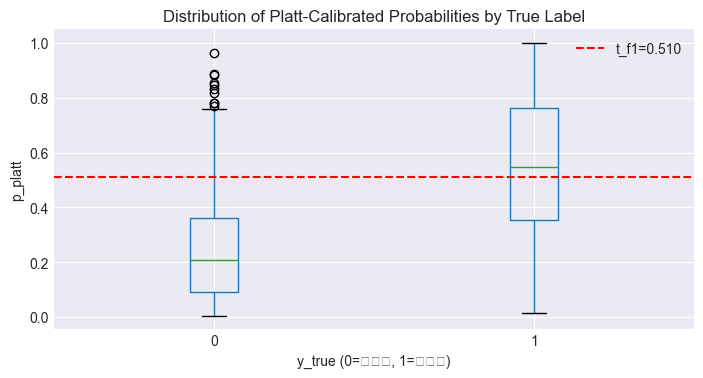

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv", parse_dates=['mdate'])
preds['y_pred_platt'] = (preds['p_platt'] >= threshold).astype(int)
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 4))
preds.boxplot(column='p_platt', by='y_true', ax=ax)
ax.axhline(threshold, color='red', linestyle='--', label=f't_f1={threshold:.3f}')
ax.set_title('Distribution of Platt-Calibrated Probabilities by True Label')
ax.set_xlabel('y_true (0=低風險, 1=高風險)')
ax.set_ylabel('p_platt')
ax.legend(loc='best')
fig.suptitle('')
plt.show()


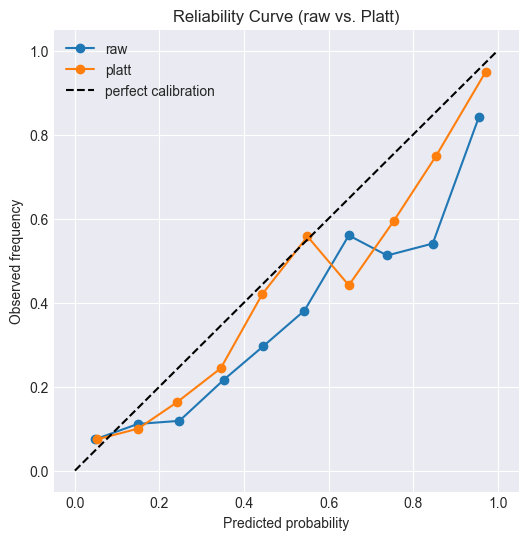

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
y_true = preds['y_true'].values
prob_raw = preds['p_raw'].values
prob_platt = preds['p_platt'].values
prob_true_raw, prob_pred_raw = calibration_curve(y_true, prob_raw, n_bins=10, strategy='uniform')
prob_true_platt, prob_pred_platt = calibration_curve(y_true, prob_platt, n_bins=10, strategy='uniform')
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred_raw, prob_true_raw, marker='o', label='raw')
ax.plot(prob_pred_platt, prob_true_platt, marker='o', label='platt')
ax.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Reliability Curve (raw vs. Platt)')
ax.legend(loc='best')
plt.show()


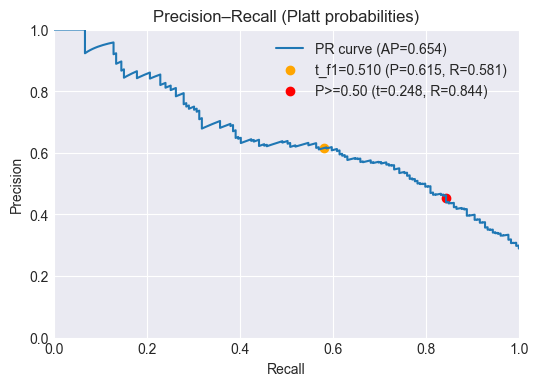

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
thresholds_info = metrics_summary['thresholds']
threshold_f1 = thresholds_info['t_f1']
threshold_p05 = thresholds_info['t_at_precision']
preds = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
y_true = preds['y_true'].values
prob_platt = preds['p_platt'].values
precision, recall, thresh = precision_recall_curve(y_true, prob_platt)
ap = average_precision_score(y_true, prob_platt)
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f'PR curve (AP={ap:.3f})')
def find_point(t):
    idx = (np.abs(thresh - t)).argmin()
    return recall[idx], precision[idx]
rec_f1, prec_f1 = find_point(threshold_f1)
rec_p05, prec_p05 = find_point(threshold_p05)
ax.scatter([rec_f1], [prec_f1], color='orange', label=f't_f1={threshold_f1:.3f} (P={prec_f1:.3f}, R={rec_f1:.3f})')
ax.scatter([rec_p05], [prec_p05], color='red', label=f'P>=0.50 (t={threshold_p05:.3f}, R={rec_p05:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall (Platt probabilities)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='best')
plt.show()


In [ ]:
import pandas as pd
predictions_test = pd.read_csv(f"{OUT_DIR}/predictions_test.csv")
exclude_cols = []
print(predictions_test.head(20))

    coid       mdate  y_true     p_raw   p_platt  p_isotonic
0   1103  2023-12-01       0  0.128336  0.123711    0.131579
1   1104  2023-12-01       0  0.017378  0.023420    0.052632
2   1108  2023-12-01       0  0.260714  0.226690    0.216667
3   1109  2023-12-01       0  0.014869  0.020573    0.052632
4   1110  2023-12-01       0  0.235982  0.207840    0.216667
5   1201  2023-12-01       0  0.434492  0.359915    0.292683
6   1203  2023-12-01       0  0.066249  0.071201    0.060976
7   1217  2023-12-01       1  0.620258  0.513776    0.508475
8   1218  2023-12-01       0  0.177086  0.162428    0.156250
9   1219  2023-12-01       0  0.403313  0.335611    0.282051
10  1220  2023-12-01       0  0.143963  0.136284    0.131579
11  1225  2023-12-01       0  0.305244  0.260526    0.216667
12  1229  2023-12-01       0  0.364114  0.305411    0.282051
13  1231  2023-12-01       0  0.163569  0.151830    0.156250
14  1233  2023-12-01       0  0.228386  0.202033    0.216667
15  1235  2023-12-01    